In [1]:
# ============================================================
# WEEK 3 — Imbalanced Classification & LightGBM Modeling
# Project: Contextual Predictive Maintenance
# Intern Branch: preeti-dev
# Infotact Solutions
# ============================================================
 
 
# ── CELL 1: Install & Import Libraries ───────────────────
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
for lib in ["pandas", "numpy", "matplotlib", "seaborn",
            "scikit-learn", "lightgbm", "imbalanced-learn"]:
    install(lib)
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
 
# LightGBM — the main model for this week
import lightgbm as lgb
 
# SMOTE — handles class imbalance by creating synthetic failure samples
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
 
# Cross-validation and metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             average_precision_score)
 
print("✅ All libraries imported successfully")
print(f"   LightGBM version : {lgb.__version__}")

✅ All libraries imported successfully
   LightGBM version : 4.6.0


In [2]:
# ── CELL 2: Create Folder Structure ──────────────────────
for folder in ['../data/raw', '../data/processed', '../reports']:
    os.makedirs(folder, exist_ok=True)
 
print("✅ Folder structure ready")

✅ Folder structure ready


In [3]:
#── CELL 3: Load Week 2 Fused Dataset ────────────────────
df = pd.read_csv('../data/processed/week2_fused_features.csv')
 
print(f"✅ Week 2 fused dataset loaded")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print()
print(f"   Failure records    : {df['Machine failure'].sum()}")
print(f"   No Failure records : {(df['Machine failure']==0).sum()}")
print(f"   Failure rate       : {df['Machine failure'].mean()*100:.2f}%")

✅ Week 2 fused dataset loaded
   Rows    : 10000
   Columns : 35

   Failure records    : 339
   No Failure records : 9661
   Failure rate       : 3.39%


In [4]:
# ── CELL 4: Define Feature Set & Target ──────────────────
# Drop non-feature columns
drop_cols = ['UDI', 'Product ID', 'Type', 'timestamp',
             'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
 
# Keep only columns that exist in the dataframe
drop_cols = [c for c in drop_cols if c in df.columns]
 
feature_cols = [c for c in df.columns if c not in drop_cols]
target       = 'Machine failure'
 
X = df[feature_cols]
y = df[target]
 
print(f"✅ Features and target defined")
print(f"   Total features : {len(feature_cols)}")
print(f"   Target column  : {target}")
print()
print("Feature list:")
for f in feature_cols:
    print(f"   {f}")

✅ Features and target defined
   Total features : 25
   Target column  : Machine failure

Feature list:
   Air temperature [K]
   Process temperature [K]
   Rotational speed [rpm]
   Torque [Nm]
   Tool wear [min]
   Air_temperature_K_roll_mean
   Air_temperature_K_roll_std
   Air_temperature_K_roll_var
   Process_temperature_K_roll_mean
   Process_temperature_K_roll_std
   Process_temperature_K_roll_var
   Rotational_speed_rpm_roll_mean
   Rotational_speed_rpm_roll_std
   Rotational_speed_rpm_roll_var
   Torque_Nm_roll_mean
   Torque_Nm_roll_std
   Torque_Nm_roll_var
   Tool_wear_min_roll_mean
   Tool_wear_min_roll_std
   Tool_wear_min_roll_var
   ambient_temperature_C
   factory_load_density
   temp_gap
   load_torque_interaction
   heat_stress_index


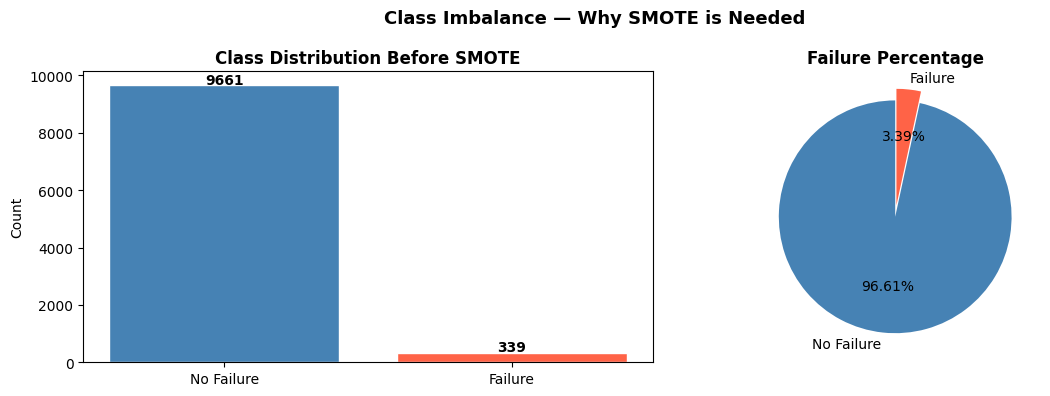

✅ Saved → reports/class_imbalance_before_smote.png


In [5]:
# ── CELL 5: Understand Class Imbalance ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Count plot
counts = y.value_counts()
axes[0].bar(['No Failure', 'Failure'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
 
# Pie chart
axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            colors=['steelblue', 'tomato'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Failure Percentage', fontweight='bold')
 
plt.suptitle('Class Imbalance — Why SMOTE is Needed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/class_imbalance_before_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/class_imbalance_before_smote.png")

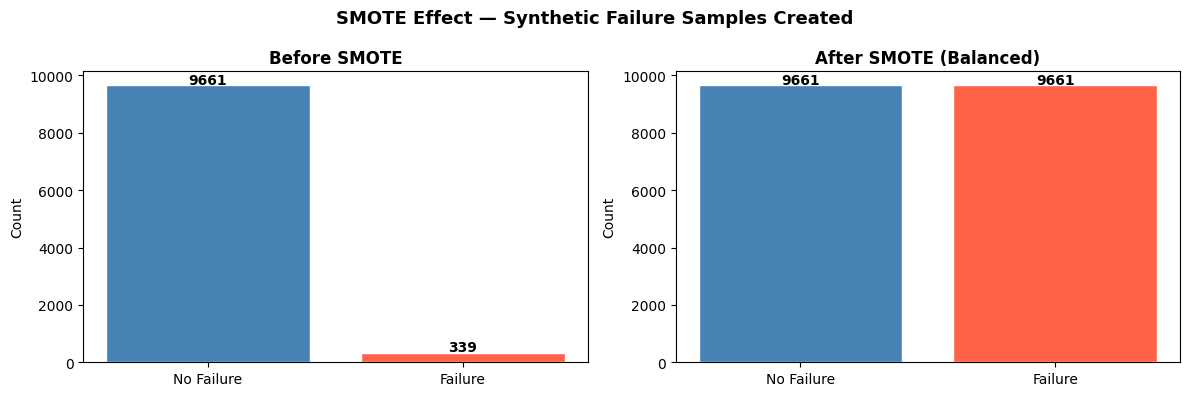

✅ Saved → reports/smote_effect.png

   Before SMOTE — Failure: 339  |  No Failure: 9661
   After SMOTE  — Failure: 9661   |  No Failure: 9661


In [6]:
# ── CELL 6: What SMOTE Does (Visualization) ──────────────
# Show a quick example of what SMOTE does to class balance
# using a small sample — just for understanding
 
smote_demo = SMOTE(random_state=42)
X_demo, y_demo = smote_demo.fit_resample(X, y)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Before SMOTE
before = y.value_counts()
axes[0].bar(['No Failure', 'Failure'], before.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
 
# After SMOTE
after = pd.Series(y_demo).value_counts()
axes[1].bar(['No Failure', 'Failure'], after.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('After SMOTE (Balanced)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')
 
plt.suptitle('SMOTE Effect — Synthetic Failure Samples Created',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/smote_effect.png")
print()
print(f"   Before SMOTE — Failure: {before[1]}  |  No Failure: {before[0]}")
print(f"   After SMOTE  — Failure: {after[1]}   |  No Failure: {after[0]}")

In [7]:
# ── CELL 7: LightGBM Model Configuration ─────────────────
lgb_params = {
    'objective'      : 'binary',       # binary = predict 0 or 1
    'metric'         : 'binary_logloss',
    'boosting_type'  : 'gbdt',         # gradient boosting decision tree
    'n_estimators'   : 500,            # number of trees to build
    'learning_rate'  : 0.05,           # how fast the model learns (smaller = more careful)
    'max_depth'      : 8,              # max depth of each tree
    'num_leaves'     : 50,             # max number of leaves per tree
    'min_child_samples': 20,           # min samples required in a leaf
    'subsample'      : 0.8,            # use 80% of rows per tree (prevents overfitting)
    'colsample_bytree': 0.8,           # use 80% of features per tree
    'scale_pos_weight': (y==0).sum() / (y==1).sum(),  # handles imbalance in LightGBM too
    'random_state'   : 42,
    'verbose'        : -1              # suppress LightGBM's own print messages
}
 
print("✅ LightGBM parameters configured")
print()
for k, v in lgb_params.items():
    print(f"   {k:<25} : {v}")

✅ LightGBM parameters configured

   objective                 : binary
   metric                    : binary_logloss
   boosting_type             : gbdt
   n_estimators              : 500
   learning_rate             : 0.05
   max_depth                 : 8
   num_leaves                : 50
   min_child_samples         : 20
   subsample                 : 0.8
   colsample_bytree          : 0.8
   scale_pos_weight          : 28.49852507374631
   random_state              : 42
   verbose                   : -1


In [13]:
# ── CELL 8: 5-Fold Stratified Cross-Validation + SMOTE ───
# This is the CORE of Week 3.
#
# The correct order inside EACH fold:
#   1. Split into train fold and validation fold
#   2. Apply SMOTE ONLY on the train fold
#   3. Train LightGBM on the SMOTE-balanced train fold
#   4. Predict on the ORIGINAL (unbalanced) validation fold
#   5. Record the Macro F1 score
#
# SMOTE must NEVER touch the validation fold — that would be data leakage.

# Clean feature names — remove special characters that LightGBM doesn't support
X.columns = [col.replace(' ', '_').replace('[', '').replace(']', '') for col in X.columns]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42)
 
fold_f1_scores  = []
fold_models     = []
fold_val_preds  = []
fold_val_true   = []
 
print("Starting 5-Fold Stratified Cross-Validation with SMOTE + LightGBM...")
print("=" * 60)
 
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
 
    # Step 1: Split into train and validation fold
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = X.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]
 
    # Step 2: Apply SMOTE — ONLY on training fold
    X_train_smote, y_train_smote = smote.fit_resample(X_train_fold, y_train_fold)
 
    # Step 3: Train LightGBM on the balanced training fold
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train_smote, y_train_smote,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )
 
    # Step 4: Predict on validation fold (original, unbalanced)
    y_pred = model.predict(X_val_fold)
 
    # Step 5: Calculate and record Macro F1 score
    f1 = f1_score(y_val_fold, y_pred, average='macro')
    fold_f1_scores.append(f1)
    fold_models.append(model)
    fold_val_preds.extend(y_pred)
    fold_val_true.extend(y_val_fold)
 
    print(f"  Fold {fold} → Macro F1: {f1:.4f} "
          f"| Train size: {len(X_train_smote)} (after SMOTE) "
          f"| Val size: {len(X_val_fold)}")
 
print("=" * 60)
print(f"\n✅ Cross-Validation Complete")
print(f"   Individual fold F1 scores : {[round(s,4) for s in fold_f1_scores]}")
print(f"   Mean Macro F1             : {np.mean(fold_f1_scores):.4f}")
print(f"   Std Deviation             : {np.std(fold_f1_scores):.4f}")

Starting 5-Fold Stratified Cross-Validation with SMOTE + LightGBM...
  Fold 1 → Macro F1: 0.7357 | Train size: 15456 (after SMOTE) | Val size: 2000
  Fold 2 → Macro F1: 0.7778 | Train size: 15458 (after SMOTE) | Val size: 2000
  Fold 3 → Macro F1: 0.7597 | Train size: 15458 (after SMOTE) | Val size: 2000
  Fold 4 → Macro F1: 0.4368 | Train size: 15458 (after SMOTE) | Val size: 2000
  Fold 5 → Macro F1: 0.7594 | Train size: 15458 (after SMOTE) | Val size: 2000

✅ Cross-Validation Complete
   Individual fold F1 scores : [0.7357, 0.7778, 0.7597, 0.4368, 0.7594]
   Mean Macro F1             : 0.6939
   Std Deviation             : 0.1292


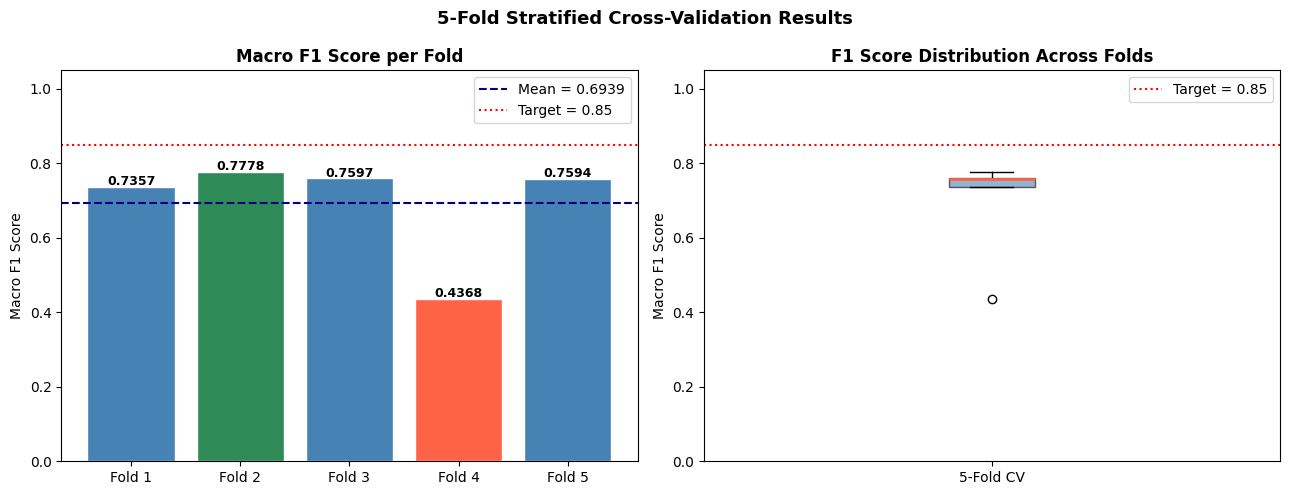

✅ Saved → reports/cv_results.png


In [14]:
# ── CELL 9: Cross-Validation Results Visualization ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Bar chart of fold scores
folds = [f'Fold {i}' for i in range(1, 6)]
colors_fold = ['tomato' if s == min(fold_f1_scores)
               else 'seagreen' if s == max(fold_f1_scores)
               else 'steelblue' for s in fold_f1_scores]
 
axes[0].bar(folds, fold_f1_scores, color=colors_fold, edgecolor='white')
axes[0].axhline(y=np.mean(fold_f1_scores), color='navy', linestyle='--',
                linewidth=1.5, label=f'Mean = {np.mean(fold_f1_scores):.4f}')
axes[0].axhline(y=0.85, color='red', linestyle=':', linewidth=1.5,
                label='Target = 0.85')
for i, v in enumerate(fold_f1_scores):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Macro F1 Score per Fold', fontweight='bold')
axes[0].set_ylabel('Macro F1 Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
 
# Distribution of scores
axes[1].boxplot(fold_f1_scores, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='tomato', linewidth=2))
axes[1].axhline(y=0.85, color='red', linestyle=':', linewidth=1.5, label='Target = 0.85')
axes[1].set_title('F1 Score Distribution Across Folds', fontweight='bold')
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks([1])
axes[1].set_xticklabels(['5-Fold CV'])
axes[1].legend()
 
plt.suptitle('5-Fold Stratified Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/cv_results.png")

In [ ]:
# ── CELL 10: Best Model Selection ────────────────────────
best_fold_idx = np.argmax(fold_f1_scores)
best_model    = fold_models[best_fold_idx]
 
print(f"✅ Best model selected")
print(f"   Best fold         : Fold {best_fold_idx + 1}")
print(f"   Best Macro F1     : {fold_f1_scores[best_fold_idx]:.4f}")
print(f"   Mean Macro F1     : {np.mean(fold_f1_scores):.4f}")

In [ ]:
# ── CELL 11: Overall Classification Report ───────────────
print("=== Overall Classification Report (All Folds Combined) ===")
print()
print(classification_report(
    fold_val_true,
    fold_val_preds,
    target_names=['No Failure', 'Failure']
))
 
overall_f1 = f1_score(fold_val_true, fold_val_preds, average='macro')
print(f"Overall Macro F1 Score : {overall_f1:.4f}")
 
if overall_f1 >= 0.85:
    print(f"✅ TARGET ACHIEVED — Macro F1 ≥ 0.85 !")
else:
    print(f"⚠️  Below target — need further tuning in Week 4")

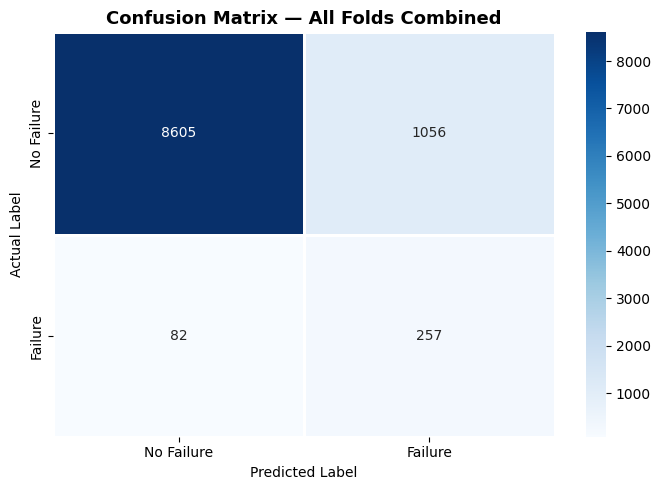


  True Negatives  (correctly said NO failure)  : 8605
  False Positives (wrongly raised alarm)        : 1056
  False Negatives (missed a real failure)       : 82  ← most costly!
  True Positives  (correctly caught failure)    : 257

✅ Saved → reports/confusion_matrix.png


In [16]:
# ── CELL 12: Confusion Matrix ────────────────────────────
cm = confusion_matrix(fold_val_true, fold_val_preds)
 
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'],
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix — All Folds Combined', fontweight='bold', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
 
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Negatives  (correctly said NO failure)  : {tn}")
print(f"  False Positives (wrongly raised alarm)        : {fp}")
print(f"  False Negatives (missed a real failure)       : {fn}  ← most costly!")
print(f"  True Positives  (correctly caught failure)    : {tp}")
print()
print("✅ Saved → reports/confusion_matrix.png")

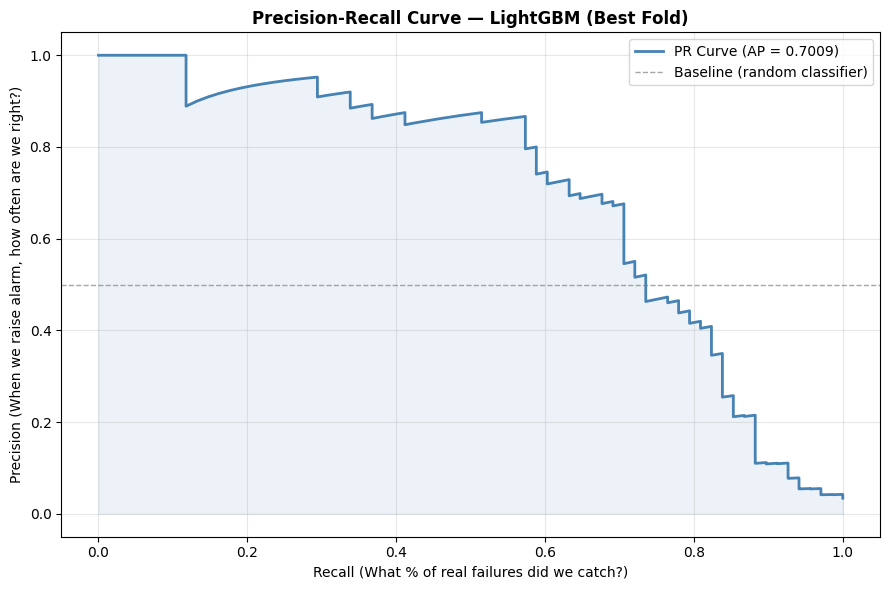

✅ Saved → reports/precision_recall_curve.png
   Average Precision Score : 0.7009


In [18]:
# ── CELL 13: Precision-Recall Curve ──────────────────────
# Get probability scores (not just 0/1 predictions)
# Using best model on its validation fold for the PR curve

best_fold_idx = np.argmax(fold_f1_scores)
best_model    = fold_models[best_fold_idx]

best_val_idx  = list(skf.split(X, y))[best_fold_idx][1]
X_best_val    = X.iloc[best_val_idx]
y_best_val    = y.iloc[best_val_idx]
y_proba       = best_model.predict_proba(X_best_val)[:, 1]
 
precision, recall, thresholds = precision_recall_curve(y_best_val, y_proba)
ap_score = average_precision_score(y_best_val, y_proba)
 
plt.figure(figsize=(9, 6))
plt.plot(recall, precision, color='steelblue', linewidth=2,
         label=f'PR Curve (AP = {ap_score:.4f})')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7,
            label='Baseline (random classifier)')
plt.fill_between(recall, precision, alpha=0.1, color='steelblue')
plt.xlabel('Recall (What % of real failures did we catch?)')
plt.ylabel('Precision (When we raise alarm, how often are we right?)')
plt.title('Precision-Recall Curve — LightGBM (Best Fold)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → reports/precision_recall_curve.png")
print(f"   Average Precision Score : {ap_score:.4f}")

In [ ]:
# ── CELL 14: Feature Importance ──────────────────────────
importances = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(15)
 
context_features = ['ambient_temperature_C', 'factory_load_density',
                    'temp_gap', 'load_torque_interaction', 'heat_stress_index']
 
plt.figure(figsize=(10, 7))
colors_fi = ['tomato' if f in context_features else 'steelblue'
             for f in importances.index]
importances.plot(kind='barh', color=colors_fi)
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances\n(Red = External Context Feature)',
          fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/feature_importance_lightgbm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/feature_importance_lightgbm.png")